# Car's Price Predictor

## Importing the necessary packages

In [1]:
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import r2_score
from lightgbm import LGBMRegressor
import joblib

## Exploratory Data Analysis

In [2]:
df = pd.read_csv('mercedes_data_full.csv')

In [3]:
df.head()

,title,price,mileage,dealer,rating,review_count,url,exterior_color,interior_color,drivetrain,mpg,engine,transmission,features,seller_address,seller_phone
0,2025 Mercedes-Benz E-Class 4MATIC,65478,7926,Mercedes-Benz of Centerville,4.7,123.0,https://www.cars.com/vehicledetail/3497db39-7f...,polar white,black mb-tex,all-wheel drive,22-31,"3l i-6 gasoline direct injection, dohc, variab...",automatic,Heated Seats; Heated Steering Wheel; Keyless E...,"1 Loop Rd., Centerville, OH 45459",NaN
1,2024 Mercedes-Benz GLE 350 Base 4MATIC,59000,20940,Mercedes-Benz of Albuquerque,4.6,3767.0,https://www.cars.com/vehicledetail/7f4042ad-45...,cirrus silver metallic,black,all-wheel drive,20-27,2.0l i4 16v gdi dohc turbo,9-speed automatic,Heated Seats; Keyless Entry; Navigation System...,"8900 Pan American Fwy NE,, Albuquerque, NM 87113",NaN
2,2024 Mercedes-Benz S-Class S 500 4MATIC,95800,11484,Mercedes-Benz of Beaverton,4.4,3086.0,https://www.cars.com/vehicledetail/6acf8a5c-e7...,obsidian black metallic,black,all-wheel drive,21-31,3.0l i6 24v gdi dohc turbo,9-speed automatic,Adaptive Cruise Control; Heated Seats; Keyless...,"9275 Southwest Canyon Road, Portland, OR 97225",NaN
3,2025 Mercedes-Benz E-Class Base,80400,2153,Mercedes-Benz of Fayetteville,4.9,1470.0,https://www.cars.com/vehicledetail/882757cd-f7...,black,black,all-wheel drive,NaN,3.0l i6 24v gdi dohc turbo hybrid,9-speed automatic,Adaptive Cruise Control; Heated Seats; Heated ...,"420 Glensford Dr, Fayetteville, NC 28314",NaN
4,2023 Mercedes-Benz E-Class 4MATIC,52999,39611,Autobahn Motors,4.7,1965.0,https://www.cars.com/vehicledetail/b44bfed6-61...,gray,black,all-wheel drive,23-31,"3l i-6 gasoline direct injection, dohc, variab...",automatic,Heated Seats; Keyless Entry; Keyless Start; Na...,"700 Island Pkwy, Belmont, CA 94002",NaN


In [4]:
df.shape

(9989, 16)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9989 entries, 0 to 9988
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           9989 non-null   object 
 1   price           9989 non-null   int64  
 2   mileage         9989 non-null   int64  
 3   dealer          9989 non-null   object 
 4   rating          9824 non-null   float64
 5   review_count    9824 non-null   float64
 6   url             9989 non-null   object 
 7   exterior_color  9953 non-null   object 
 8   interior_color  9811 non-null   object 
 9   drivetrain      7610 non-null   object 
 10  mpg             6863 non-null   object 
 11  engine          7512 non-null   object 
 12  transmission    7521 non-null   object 
 13  features        7487 non-null   object 
 14  seller_address  9989 non-null   object 
 15  seller_phone    0 non-null      float64
dtypes: float64(3), int64(2), object(11)
memory usage: 1.2+ MB


In [6]:
df.isnull().sum()

title                0
price                0
mileage              0
dealer               0
rating             165
review_count       165
url                  0
exterior_color      36
interior_color     178
drivetrain        2379
mpg               3126
engine            2477
transmission      2468
features          2502
seller_address       0
seller_phone      9989
dtype: int64

In [7]:
df = df.drop(['dealer', 'url', 'seller_address', 'seller_phone', 'rating', 'review_count'], axis = 1)

In [8]:
df['mileage'].describe()

count    9.989000e+03
mean     1.971152e+04
std      5.277611e+04
min      1.020000e+02
25%      5.251000e+03
50%      1.190400e+04
75%      2.944100e+04
max      4.949608e+06
Name: mileage, dtype: float64

In [9]:
df['mileage'] = df['mileage'].apply(lambda x : x if x <= 500000 else df['mileage'].median())

In [10]:
df['mileage'].describe()

count      9989.000000
mean      19217.208529
std       18755.571532
min         102.000000
25%        5251.000000
50%       11904.000000
75%       29412.000000
max      304037.000000
Name: mileage, dtype: float64

## Feature Engineering

In [11]:
df['car_year'] = df['title'].str.extract(r'(\d{4})').astype(float)

In [12]:
df['mo'] = df['title'].str.replace(r'\s*\d{4}\s*', ' ', regex = True)
df['mod'] = df['mo'].str.replace(r'\s*Base\s*', ' ', regex = True)
df['mode'] = df['mod'].str.replace(r'\s*Coupe\s*', ' ', regex = True)
df['model'] = df['mode'].str.replace(r'\b4MAT\w*\b', ' ', regex = True).str.strip()

In [13]:
df = df.drop(['mo', 'mod', 'mode', 'title'], axis = 1)

In [14]:
df.head()

,price,mileage,exterior_color,interior_color,drivetrain,mpg,engine,transmission,features,car_year,model
0,65478,7926.0,polar white,black mb-tex,all-wheel drive,22-31,"3l i-6 gasoline direct injection, dohc, variab...",automatic,Heated Seats; Heated Steering Wheel; Keyless E...,2025.0,Mercedes-Benz E-Class
1,59000,20940.0,cirrus silver metallic,black,all-wheel drive,20-27,2.0l i4 16v gdi dohc turbo,9-speed automatic,Heated Seats; Keyless Entry; Navigation System...,2024.0,Mercedes-Benz GLE 350
2,95800,11484.0,obsidian black metallic,black,all-wheel drive,21-31,3.0l i6 24v gdi dohc turbo,9-speed automatic,Adaptive Cruise Control; Heated Seats; Keyless...,2024.0,Mercedes-Benz S-Class S 500
3,80400,2153.0,black,black,all-wheel drive,NaN,3.0l i6 24v gdi dohc turbo hybrid,9-speed automatic,Adaptive Cruise Control; Heated Seats; Heated ...,2025.0,Mercedes-Benz E-Class
4,52999,39611.0,gray,black,all-wheel drive,23-31,"3l i-6 gasoline direct injection, dohc, variab...",automatic,Heated Seats; Keyless Entry; Keyless Start; Na...,2023.0,Mercedes-Benz E-Class


In [15]:
unique_features = set()

for features_string in df['features'].dropna() :
    for feature in features_string.split(';') :
        unique_features.add(feature.strip().lower())
        
unique_features = sorted(unique_features)

print(unique_features)
print(len(unique_features))

['10 hrs. level 2 charging', '100 | outstanding battery range score', '101 city / 105 hwy. mpge', '101 | outstanding battery range score', '102 | outstanding battery range score', '103 | outstanding battery range score', '104 city / 98 hwy. mpge', '104 | outstanding battery range score', '105 | outstanding battery range score', '106 | outstanding battery range score', '107 | outstanding battery range score', '108 kwh battery capacity', '11 hrs. level 2 charging', '114 city / 100 hwy. mpge', '12 hrs. level 2 charging', '14 hrs. level 2 charging', '206-231 mi expected range', '208-232 mi expected range', '209-231 mi expected range', '210-234 mi expected range', '211-227 mi expected range', '211-234 mi expected range', '216-239 mi expected range', '218-240 mi expected range', '219-240 mi expected range', '221 mi. epa-est. range', '221-244 mi expected range', '224-244 mi expected range', '227-251 mi expected range', '228 mi expected range', '228-249 mi expected range', '229-250 mi expected

In [16]:
feature_counts = {}

for feature in unique_features:
    count = 0
    for features_string in df['features'].dropna() :
        feature_list = [f.strip().lower() for f in features_string.split(';')]
        if feature in feature_list :
            count += 1
    feature_counts[feature] = count

sorted_features = sorted(feature_counts.items(), key=lambda x : x[1], reverse=True)

for feature, count in sorted_features :
    print(f"{feature}: {count} cars")

bluetooth®: 7486 cars
stability control: 7486 cars
brake assist: 7485 cars
alloy wheels: 7470 cars
memory seat: 7460 cars
leather seats: 7454 cars
keyless entry: 7235 cars
backup camera: 7204 cars
keyless start: 6803 cars
blind spot monitor: 6771 cars
automatic emergency braking: 6697 cars
usb port: 6686 cars
apple carplay®: 6648 cars
heated seats: 6638 cars
led headlights: 6585 cars
remote start: 6457 cars
rain sensing wipers: 6217 cars
sunroof/moonroof: 5856 cars
premium sound system: 5770 cars
navigation system: 5472 cars
homelink: 5440 cars
power liftgate: 5358 cars
android auto®: 5200 cars
collision warning system: 4894 cars
dynamic steering: 4883 cars
driver monitor: 4880 cars
wifi hotspot: 4791 cars
satellite radio: 4554 cars
parking assistance: 4231 cars
headlight control - auto highbeam: 4196 cars
parking distance sensors: 4042 cars
heated steering wheel: 3134 cars
rear cross traffic alert: 3080 cars
lane departure warning: 2116 cars
cooled seats: 2109 cars
apple carplay/andro

In [17]:
important_features = []

for feature in feature_counts :
    if feature_counts[feature] >= 108 :
        important_features.append(feature)

print(important_features)
print(len(important_features))

['adaptive cruise control', 'alloy wheels', 'android auto®', 'apple carplay/android auto', 'apple carplay®', 'automatic emergency braking', 'automatic parking', 'autonomous drive', 'backup camera', 'blind spot monitor', 'bluetooth®', 'brake assist', 'cd player', 'collision warning system', 'cooled seats', 'driver monitor', 'dvd player', 'dynamic steering', 'electric fuel type', 'front cross traffic alert', 'headlight control - auto highbeam', 'heated seats', 'heated steering wheel', 'homelink', 'keyless entry', 'keyless start', 'lane departure warning', 'leather seats', 'led headlights', 'memory seat', 'navigation system', 'parking assistance', 'parking distance sensors', 'power folding mirrors', 'power liftgate', 'premium sound system', 'rain sensing wipers', 'rear cross traffic alert', 'remote start', 'roof rack', 'satellite radio', 'stability control', 'sunroof/moonroof', 'third row seating', 'tow hitch', 'tow hooks', 'traffic sign recognition', 'usb port', 'wifi hotspot']
49


In [18]:
important_features.remove('android auto®')
important_features.remove('apple carplay/android auto')
important_features.remove('apple carplay®')

In [19]:
smart_connectivity = ['android auto®', 'apple carplay/android auto', 'apple carplay®']

def get_smart_connectivity(features_string):
    features_list = [f.strip().lower() for f in str(features_string).split(';')]
    
    has_android = any('android auto®' in feature for feature in features_list)
    has_apple = any('apple carplay®' in feature for feature in features_list)
    has_both = any('apple carplay/android auto' in feature for feature in features_list)
    
    if has_both :
        return 'apple carplay/android auto'
    elif has_android :
        return 'android auto®'
    elif has_apple :
        return 'apple carplay®'

df['smart_connectivity'] = df['features'].apply(get_smart_connectivity)

In [20]:
df.head()

,price,mileage,exterior_color,interior_color,drivetrain,mpg,engine,transmission,features,car_year,model,smart_connectivity
0,65478,7926.0,polar white,black mb-tex,all-wheel drive,22-31,"3l i-6 gasoline direct injection, dohc, variab...",automatic,Heated Seats; Heated Steering Wheel; Keyless E...,2025.0,Mercedes-Benz E-Class,android auto®
1,59000,20940.0,cirrus silver metallic,black,all-wheel drive,20-27,2.0l i4 16v gdi dohc turbo,9-speed automatic,Heated Seats; Keyless Entry; Navigation System...,2024.0,Mercedes-Benz GLE 350,apple carplay®
2,95800,11484.0,obsidian black metallic,black,all-wheel drive,21-31,3.0l i6 24v gdi dohc turbo,9-speed automatic,Adaptive Cruise Control; Heated Seats; Keyless...,2024.0,Mercedes-Benz S-Class S 500,apple carplay®
3,80400,2153.0,black,black,all-wheel drive,NaN,3.0l i6 24v gdi dohc turbo hybrid,9-speed automatic,Adaptive Cruise Control; Heated Seats; Heated ...,2025.0,Mercedes-Benz E-Class,apple carplay/android auto
4,52999,39611.0,gray,black,all-wheel drive,23-31,"3l i-6 gasoline direct injection, dohc, variab...",automatic,Heated Seats; Keyless Entry; Keyless Start; Na...,2023.0,Mercedes-Benz E-Class,apple carplay/android auto


In [21]:
df.isnull().sum()

price                    0
mileage                  0
exterior_color          36
interior_color         178
drivetrain            2379
mpg                   3126
engine                2477
transmission          2468
features              2502
car_year                 0
model                    0
smart_connectivity    3159
dtype: int64

In [22]:
for feature in important_features:
    df[feature] = [1 if pd.notna(f) and feature in [item.strip() for item in f.split(';')] 
                   else 0 for f in df['features']]

In [23]:
df = df.drop(['features'], axis = 1)

In [24]:
df.head()

,price,mileage,exterior_color,interior_color,drivetrain,mpg,engine,transmission,car_year,model,...,roof rack,satellite radio,stability control,sunroof/moonroof,third row seating,tow hitch,tow hooks,traffic sign recognition,usb port,wifi hotspot
0,65478,7926.0,polar white,black mb-tex,all-wheel drive,22-31,"3l i-6 gasoline direct injection, dohc, variab...",automatic,2025.0,Mercedes-Benz E-Class,...,0,0,0,0,0,0,0,0,0,0
1,59000,20940.0,cirrus silver metallic,black,all-wheel drive,20-27,2.0l i4 16v gdi dohc turbo,9-speed automatic,2024.0,Mercedes-Benz GLE 350,...,0,0,0,0,0,0,0,0,0,0
2,95800,11484.0,obsidian black metallic,black,all-wheel drive,21-31,3.0l i6 24v gdi dohc turbo,9-speed automatic,2024.0,Mercedes-Benz S-Class S 500,...,0,0,0,0,0,0,0,1,0,0
3,80400,2153.0,black,black,all-wheel drive,NaN,3.0l i6 24v gdi dohc turbo hybrid,9-speed automatic,2025.0,Mercedes-Benz E-Class,...,0,0,0,0,0,0,0,0,0,0
4,52999,39611.0,gray,black,all-wheel drive,23-31,"3l i-6 gasoline direct injection, dohc, variab...",automatic,2023.0,Mercedes-Benz E-Class,...,0,0,0,0,0,0,0,1,0,0


In [25]:
def extract_engine_size(engine_str) :
    
    match = re.search(r'(\d+\.?\d*)\s*l', str(engine_str).lower())
    if match :
        return float(match.group(1))
    return None

df['engine_size'] = df['engine'].apply(extract_engine_size)


def is_electric(engine_str) :
    
    electric_patterns = ['electric', 'ev', 'phev', 'plug-in', 'battery', 'hybrid']
    engine_lower = str(engine_str).lower()
    
    for pattern in electric_patterns:
        if re.search(pattern, engine_lower) :
            return 1
    return 0

df['is_electric'] = df['engine'].apply(is_electric)

In [26]:
df = df.drop(['engine'], axis = 1)

In [27]:
df.head()

,price,mileage,exterior_color,interior_color,drivetrain,mpg,transmission,car_year,model,smart_connectivity,...,stability control,sunroof/moonroof,third row seating,tow hitch,tow hooks,traffic sign recognition,usb port,wifi hotspot,engine_size,is_electric
0,65478,7926.0,polar white,black mb-tex,all-wheel drive,22-31,automatic,2025.0,Mercedes-Benz E-Class,android auto®,...,0,0,0,0,0,0,0,0,3.0,0
1,59000,20940.0,cirrus silver metallic,black,all-wheel drive,20-27,9-speed automatic,2024.0,Mercedes-Benz GLE 350,apple carplay®,...,0,0,0,0,0,0,0,0,2.0,0
2,95800,11484.0,obsidian black metallic,black,all-wheel drive,21-31,9-speed automatic,2024.0,Mercedes-Benz S-Class S 500,apple carplay®,...,0,0,0,0,0,1,0,0,3.0,0
3,80400,2153.0,black,black,all-wheel drive,NaN,9-speed automatic,2025.0,Mercedes-Benz E-Class,apple carplay/android auto,...,0,0,0,0,0,0,0,0,3.0,1
4,52999,39611.0,gray,black,all-wheel drive,23-31,automatic,2023.0,Mercedes-Benz E-Class,apple carplay/android auto,...,0,0,0,0,0,1,0,0,3.0,0


In [28]:
def extract_mpg(mpg_str):
    
    if pd.isna(mpg_str) or mpg_str == 'N/A':
        return (None, None)
        
    try:
        if '-' in str(mpg_str):
            city, highway = str(mpg_str).split('-')
            return (float(city.strip()), float(highway.strip()))
    except:
        return (None, None)

result = df['mpg'].apply(extract_mpg)
df['mpg_city'] = result.apply(lambda x : x[0])
df['mpg_highway'] = result.apply(lambda x : x[1])

In [29]:
df = df.drop(['mpg'], axis = 1)

In [30]:
df.head()

,price,mileage,exterior_color,interior_color,drivetrain,transmission,car_year,model,smart_connectivity,adaptive cruise control,...,third row seating,tow hitch,tow hooks,traffic sign recognition,usb port,wifi hotspot,engine_size,is_electric,mpg_city,mpg_highway
0,65478,7926.0,polar white,black mb-tex,all-wheel drive,automatic,2025.0,Mercedes-Benz E-Class,android auto®,0,...,0,0,0,0,0,0,3.0,0,22.0,31.0
1,59000,20940.0,cirrus silver metallic,black,all-wheel drive,9-speed automatic,2024.0,Mercedes-Benz GLE 350,apple carplay®,0,...,0,0,0,0,0,0,2.0,0,20.0,27.0
2,95800,11484.0,obsidian black metallic,black,all-wheel drive,9-speed automatic,2024.0,Mercedes-Benz S-Class S 500,apple carplay®,0,...,0,0,0,1,0,0,3.0,0,21.0,31.0
3,80400,2153.0,black,black,all-wheel drive,9-speed automatic,2025.0,Mercedes-Benz E-Class,apple carplay/android auto,0,...,0,0,0,0,0,0,3.0,1,NaN,NaN
4,52999,39611.0,gray,black,all-wheel drive,automatic,2023.0,Mercedes-Benz E-Class,apple carplay/android auto,0,...,0,0,0,1,0,0,3.0,0,23.0,31.0


In [31]:
df.shape

(9989, 59)

In [32]:
y = df['price']
X = df.drop(['price'], axis = 1)

In [33]:
cat_cols = X.select_dtypes(include=["object"]).columns

for col in cat_cols:
    le = LabelEncoder()
    le_name = f"label_encoder_{col}"
    print(le_name)
    X[col] = le.fit_transform(X[col])
    joblib.dump(le, f'{le_name}.pkl')

label_encoder_exterior_color
label_encoder_interior_color
label_encoder_drivetrain
label_encoder_transmission
label_encoder_model
label_encoder_smart_connectivity


In [34]:
X.head()

,mileage,exterior_color,interior_color,drivetrain,transmission,car_year,model,smart_connectivity,adaptive cruise control,alloy wheels,...,third row seating,tow hitch,tow hooks,traffic sign recognition,usb port,wifi hotspot,engine_size,is_electric,mpg_city,mpg_highway
0,7926.0,216,150,0,20,2025.0,81,0,0,0,...,0,0,0,0,0,0,3.0,0,22.0,31.0
1,20940.0,34,115,0,15,2024.0,119,2,0,0,...,0,0,0,0,0,0,2.0,0,20.0,27.0
2,11484.0,203,115,0,15,2024.0,148,2,0,0,...,0,0,0,1,0,0,3.0,0,21.0,31.0
3,2153.0,16,115,0,15,2025.0,81,1,0,0,...,0,0,0,0,0,0,3.0,1,NaN,NaN
4,39611.0,99,115,0,20,2023.0,81,1,0,0,...,0,0,0,1,0,0,3.0,0,23.0,31.0


## Modeling and Evaluation

In [35]:
lgb_model = LGBMRegressor(
    random_state=42,
    n_estimators=300
)

y_bins = pd.qcut(y, q=5, labels = False)

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
lgb_r2_scores = cross_val_score(
    lgb_model,
    X,
    y,
    cv=skf.split(X, y_bins),
    scoring="r2",
    n_jobs=-1
)

print("LightGBM baseline R² per fold:", lgb_r2_scores)
print("Mean R²:", lgb_r2_scores.mean())

LightGBM baseline R² per fold: [0.96011327 0.96177601 0.95899301 0.95226037 0.95461947]
Mean R²: 0.9575524276938319


### Hyper Parameter Tuning

In [36]:
param_dist = {
    "n_estimators": [300, 500, 800],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [-1, 6, 8, 10],
    "num_leaves": [31, 50, 100],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
    "reg_alpha": [0, 0.1, 0.5],
    "reg_lambda": [0, 0.1, 0.5]
}

lgb = LGBMRegressor(random_state=42)

y_bins = pd.qcut(y, q=5, labels = False)

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

random_search = RandomizedSearchCV(
    estimator=lgb,
    param_distributions=param_dist,
    n_iter=30,
    scoring="r2",
    cv=skf.split(X, y_bins),
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X, y)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000395 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 880
[LightGBM] [Info] Number of data points in the train set: 9989, number of used features: 21
[LightGBM] [Info] Start training from score 52232.652818
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LGBMRegressor(random_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 0.8, ...], 'learning_rate': [0.01, 0.03, ...], 'max_depth': [-1, 6, ...], 'n_estimators': [300, 500, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used her

In [37]:
print("Best parameters:")
print(random_search.best_params_)

print("Best CV R²:")
print(random_search.best_score_)

Best parameters:
{'subsample': 0.8, 'reg_lambda': 0.5, 'reg_alpha': 0, 'num_leaves': 100, 'n_estimators': 800, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Best CV R²:
0.96070956182106


In [38]:
final_model = random_search.best_estimator_

In [40]:
feature_importances = pd.DataFrame({'feature': X.columns, 'importance': final_model.feature_importances_}).sort_values('importance', ascending=False)

print("Top most important features")
print()
print(feature_importances.head(24))

Top most important features

                              feature  importance
0                             mileage        4492
6                               model        3759
2                      interior_color        2707
1                      exterior_color        2245
57                        mpg_highway        1397
5                            car_year        1269
56                           mpg_city        1238
4                        transmission         615
7                  smart_connectivity         582
54                        engine_size         515
3                          drivetrain         434
18           collision warning system         152
12                   autonomous drive         135
36                 parking assistance         128
51           traffic sign recognition         106
25  headlight control - auto highbeam          86
37           parking distance sensors          81
20                     driver monitor          74
55                   

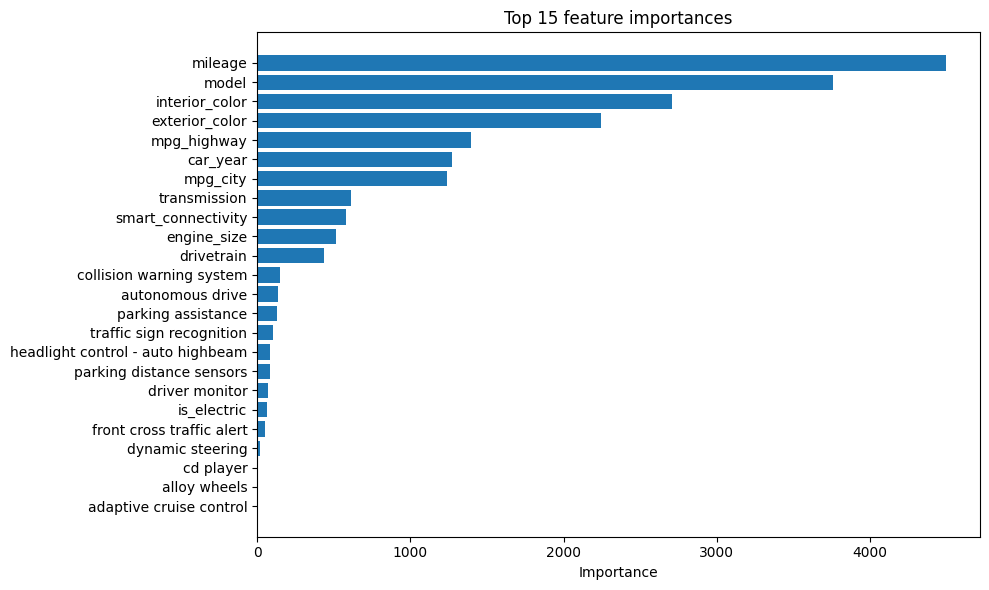

In [41]:
plt.figure(figsize=(10, 6))
top_features = feature_importances.head(24)
plt.barh(top_features['feature'], top_features['importance'])
plt.xlabel('Importance')
plt.title('Top 15 feature importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [42]:
joblib.dump(final_model, 'lgb_car_price_model.pkl')

['lgb_car_price_model.pkl']

In [43]:
joblib.dump(X.columns.tolist(), 'model_features.pkl')

['model_features.pkl']

# Prediction Example

In [44]:
model = joblib.load('label_encoder_model.pkl')
exterior_color = joblib.load('label_encoder_exterior_color.pkl')
interior_color = joblib.load('label_encoder_interior_color.pkl')
drivetrain = joblib.load('label_encoder_drivetrain.pkl')
transmission = joblib.load('label_encoder_transmission.pkl')
smart_connectivity = joblib.load('label_encoder_smart_connectivity.pkl')

new_car = pd.DataFrame({
    "mpg_mixed": [28.0],
    "model": [model.transform(['Mercedes-Benz E-Class'])[0]],
    "mileage": [41061],
    "engine_size":[ 5.0],
    "car_year": [2024.0],
    "car_age": [2.0],
    "mpg_highway": [32.0],
    "interior_color": [interior_color.transform(['black'])[0]],
    "mpg_city": [24],
    'drivetrain': [drivetrain.transform(['all-wheel drive'])[0]],
    'exterior_color': [exterior_color.transform(['gray'])[0]],
    'transmission': [transmission.transform(['automatic'])[0]],
    'smart_connectivity': [smart_connectivity.transform(['apple carplay/android auto'])[0]],
    'traffic sign recognition': [1],
    'parking distance sensors': [1],
    'autonomous drive': [0],
    'headlight control - auto highbeam': [1],
    'is_electric': [0],
    'front cross traffic alert': [1],
    'collision warning system': [1],
    'dynamic steering': [0],
    'driver monitor': [1],
    'parking assistance': [1],
    'adaptive cruise control' : [0],
    'automatic emergency braking' : [1],
    'alloy wheels': [1],
    'heated seats': [1],
    'electric fuel': [0],
    'cooled seats': [1],
    'automatic parking': [1],
    'backup camera': [1],
    'blind spot monitor': [0],
    'bluetooth®': [1],
    'brake assist': [1],
    'memory seat': [1],
    'led headlights': [1],
    'heated steering wheel': [1],
    'homelink': [0],
    'lane departure warning': [1],
    'leather seats': [1],
    'keyless entry': [1],
    'keyless start': [1],
    'rear cross traffic alert': [0],
    'rain sensing wipers': [0],
    'premium sound system': [1],
    'power liftgate': [0],
    'power folding mirrors': [0],
    'navigation system': [1],
    'remote start': [1],
    'roof rac': [1],
    'tow hooks': [0],
    'tow hitch': [0],
    'third row seating': [0],
    'sunroof/moonroof': [1],
    'stability control': [1],
    'satellite radio': [1],
    'wifi hotspot': [1],
    'usb port': [1]
})

prediction = final_model.predict(new_car)
print("Predicted price:", prediction[0])

Predicted price: 76098.39935085292
